In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbs
import plotly.express as px
import pandas as pd
from sklearn.preprocessing import LabelEncoder,MinMaxScaler,StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,root_mean_squared_error,mean_absolute_error,r2_score

# DATA AQUISTAION

In [2]:
boston=pd.read_csv(r"C:\Users\user\Downloads\boston.csv")

# CLEANING AND PREPROCESSING

In [3]:
boston

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
0,0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [4]:
boston.columns

Index(['Unnamed: 0', 'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS',
       'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'Price'],
      dtype='object')

In [5]:
boston.drop('Unnamed: 0',axis=1,inplace=True)

In [6]:
boston.dtypes   # machine predicts when data is in numbers 
                # if in categorical so we have to transform them into numbers

CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX          int64
PTRATIO    float64
B          float64
LSTAT      float64
Price      float64
dtype: object

In [7]:
boston.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
Price      0
dtype: int64

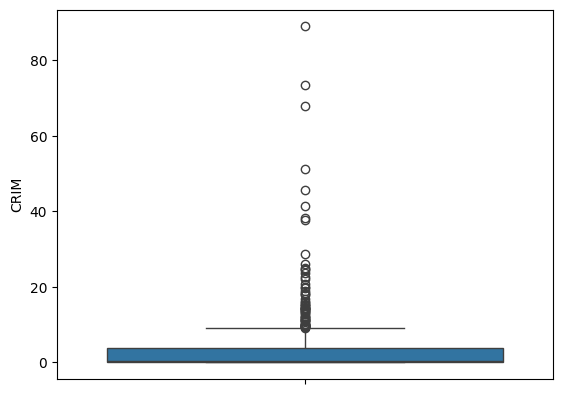

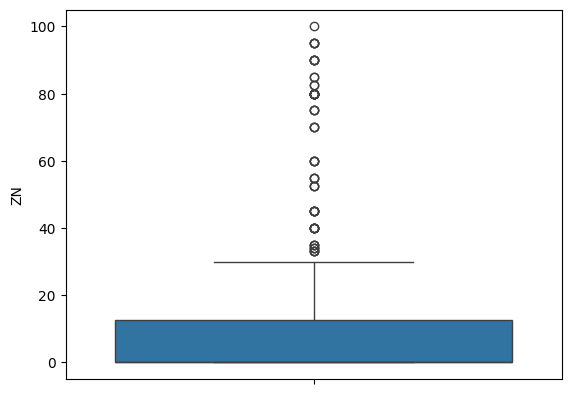

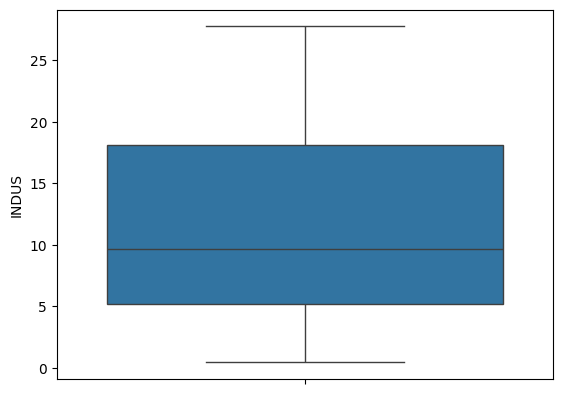

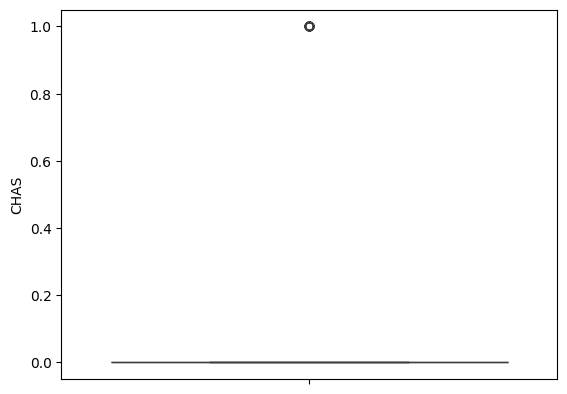

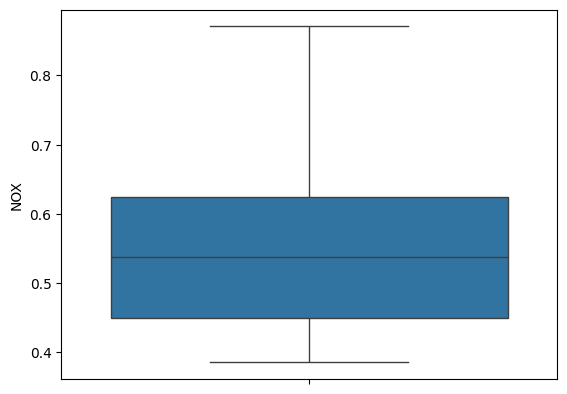

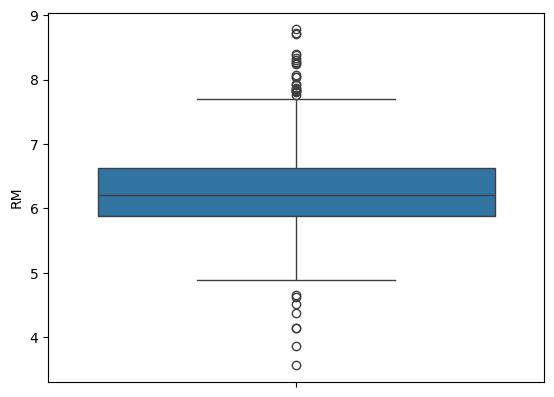

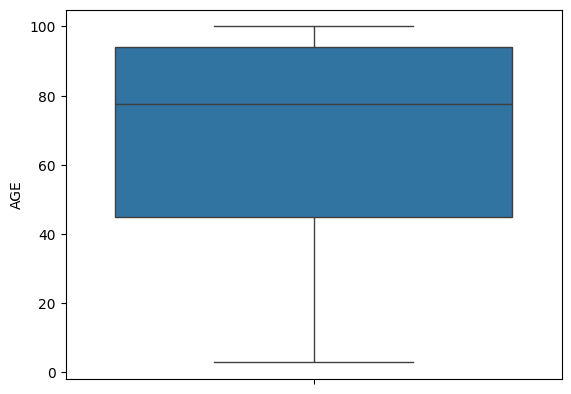

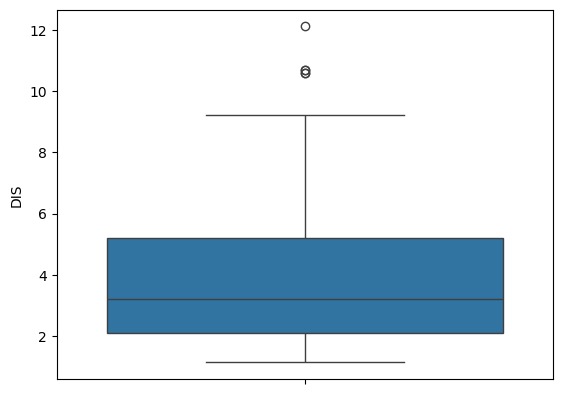

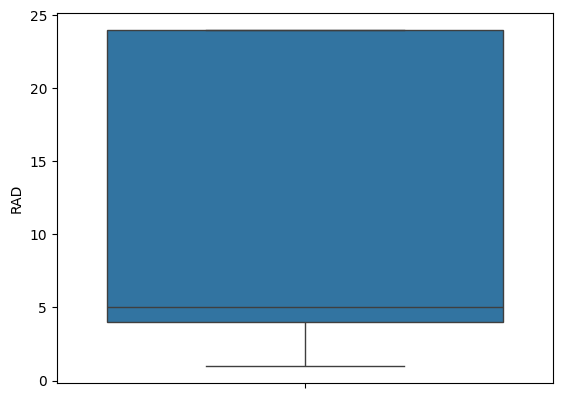

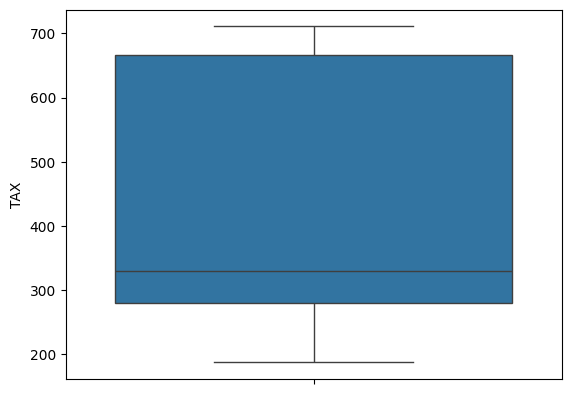

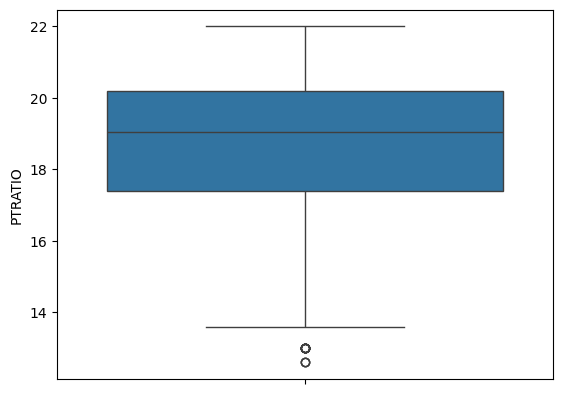

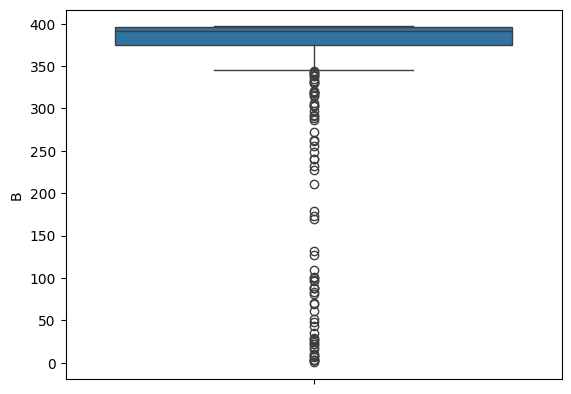

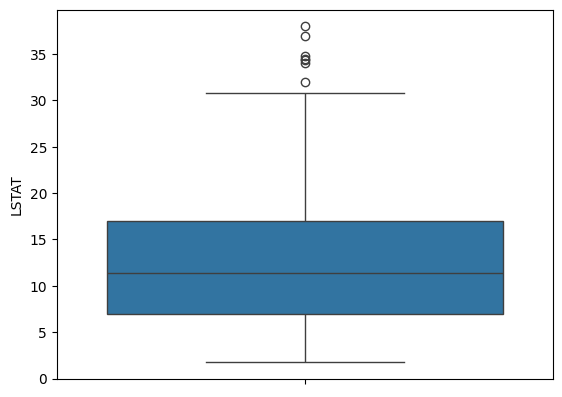

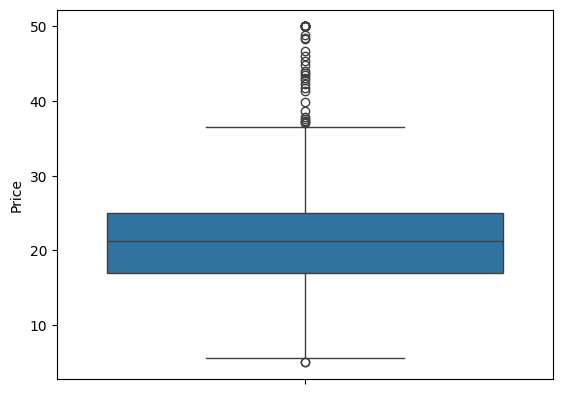

In [8]:
for col in boston.columns:
    sbs.boxplot(boston[col])
    plt.show()

# for data containing outliers

# Zscore Value

In [9]:
brows= boston.shape[0]

In [10]:
brows

506

In [11]:
for col in boston.columns:
    std= boston[col].std()*3
    mean= boston[col].mean()
    lower= mean - (std)
    upper= mean + (std)
    index= boston[col].between(lower,upper)
    boston= boston[index]
    print(f' column {col} : {boston.shape[0]}')

 column CRIM : 498
 column ZN : 484
 column INDUS : 484
 column CHAS : 450
 column NOX : 450
 column RM : 441
 column AGE : 441
 column DIS : 437
 column RAD : 437
 column TAX : 437
 column PTRATIO : 437
 column B : 414
 column LSTAT : 412
 column Price : 404


In [12]:
arows= boston[col].shape[0]

In [13]:
arows

404

In [14]:
print(f' rows with outliers:{brows} and rows without outliers:{arows}')

 rows with outliers:506 and rows without outliers:404


In [15]:
print(f' rows {col} and without outliers {boston.shape[0]}')

 rows Price and without outliers 404


In [16]:
404/506

0.7984189723320159

In [17]:
X= boston.drop('Price',axis=1)
Y=boston.Price

In [18]:
mms= MinMaxScaler()

In [19]:
X_norm= mms.fit_transform(X)

In [20]:
X_norm=pd.DataFrame(data=X_norm,columns=X.columns)

<Axes: >

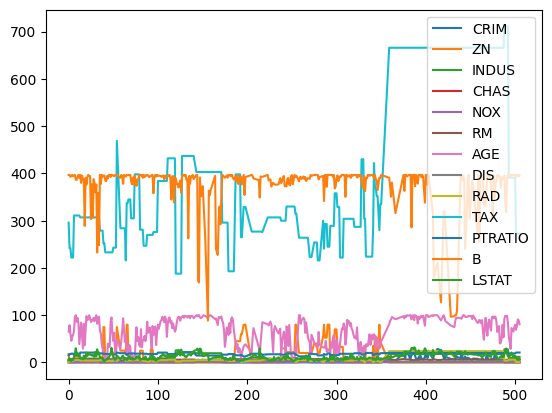

In [21]:
X.plot()

<Axes: >

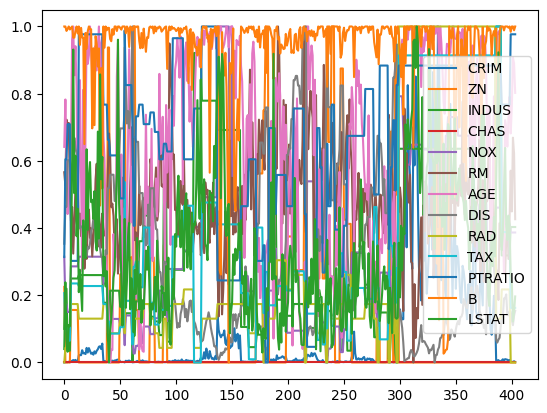

In [22]:
pd.DataFrame(data=X_norm,columns=X.columns).plot()

In [23]:
std=StandardScaler()
x_std= std.fit_transform(X)

In [24]:
X_std=pd.DataFrame(data=x_std,columns=X.columns)

<Axes: >

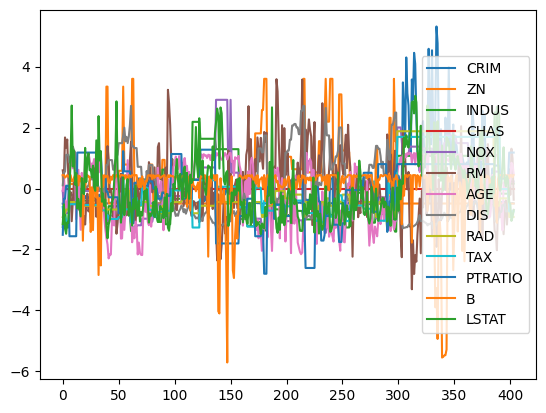

In [25]:
X_std.plot()

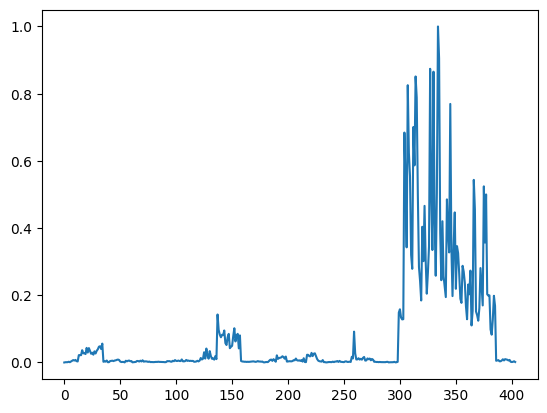

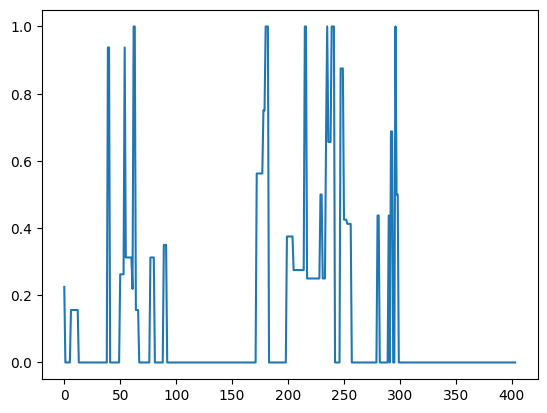

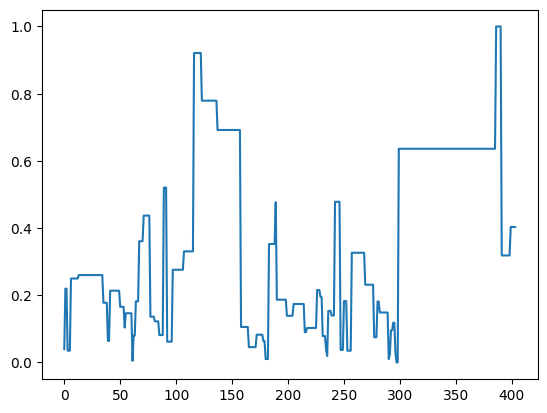

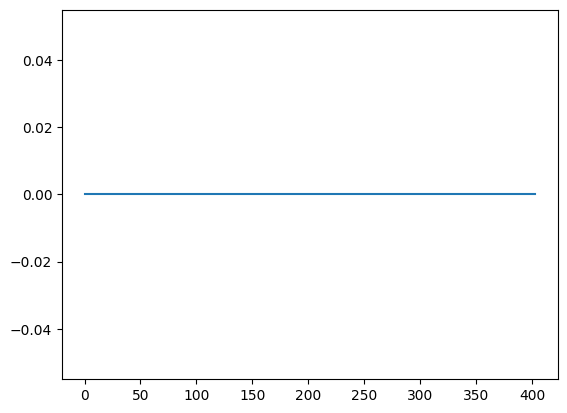

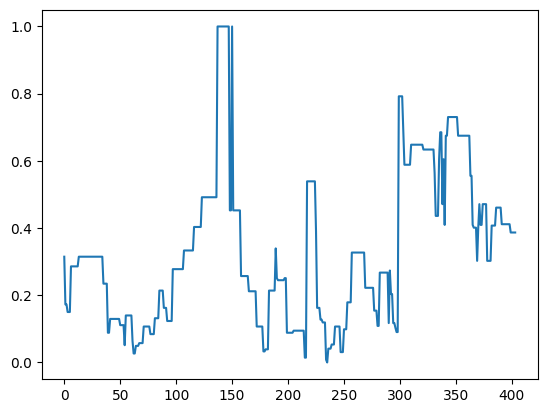

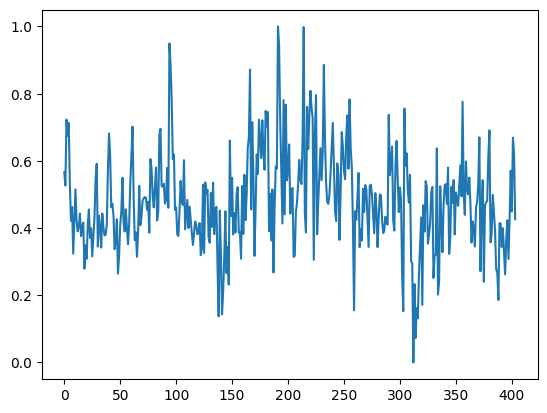

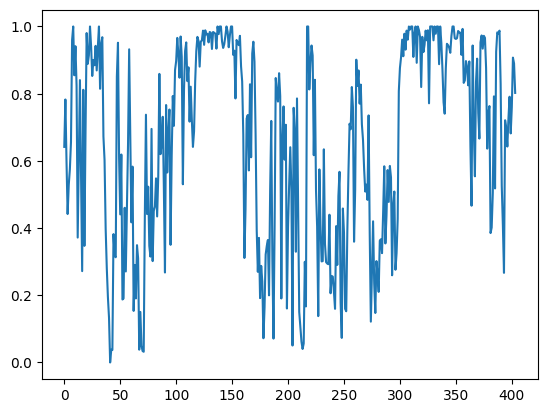

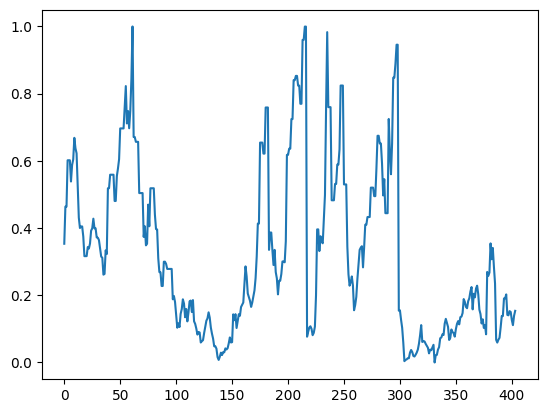

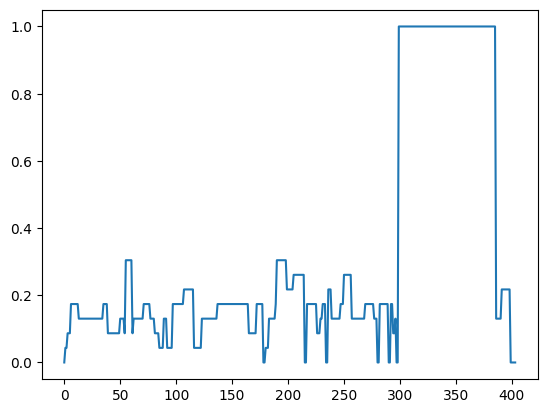

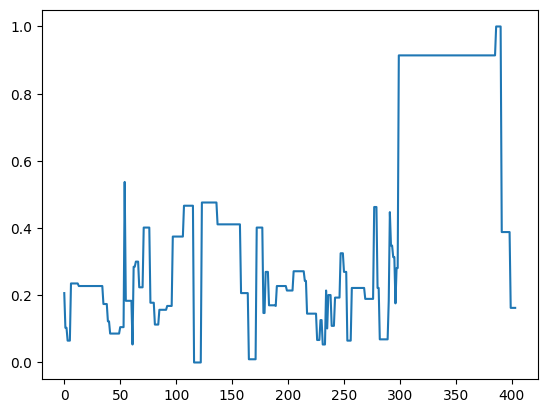

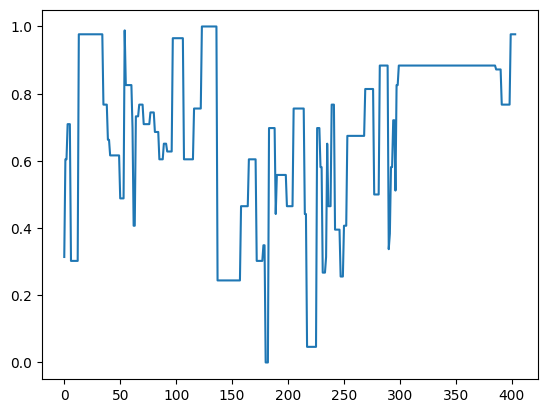

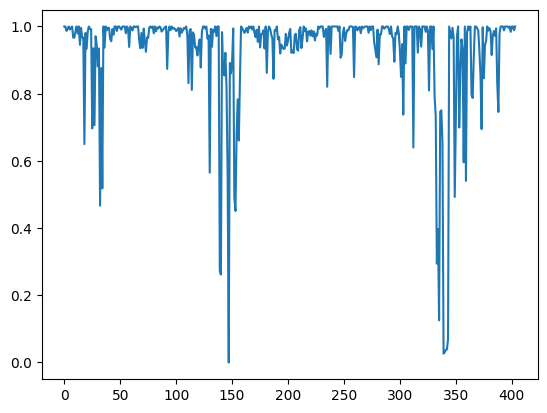

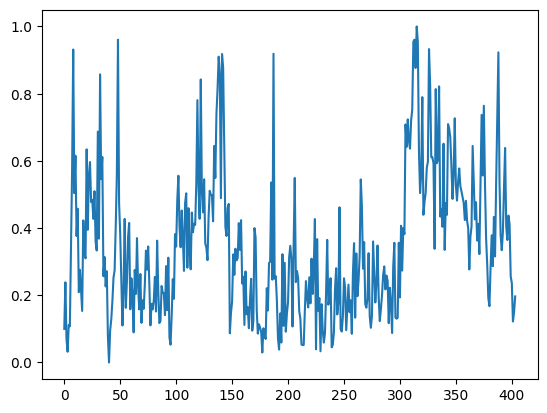

In [26]:
for col in X_norm.columns:
    X_norm[col].plot()
    plt.show()

# TRAIN(DEVELOP) TEST(EVALUATION) SPLIT

In [27]:
X_train,X_test,Y_train,Y_test= train_test_split(X,Y,test_size=0.25,random_state=42)       
NX_train,NX_test,NY_train,NY_test= train_test_split(X_norm,Y,test_size=0.25,random_state=42)     
SX_train,SX_test,SY_train,SY_test= train_test_split(X_std,Y,test_size=0.25,random_state=42)     

In [28]:
X_train= np.array(X_train)
Y_train=np.array(Y_train)
X_test= np.array(X_test)
Y_test= np.array(Y_test)

X_train= np.array(NX_train)
Y_train=np.array(NY_train)
X_test= np.array(NX_test)
Y_test= np.array(NY_test)

X_train= np.array(SX_train)
Y_train=np.array(SY_train)
X_test= np.array(SX_test)
Y_test= np.array(SY_test)


In [29]:
lr=LinearRegression()

In [30]:
lr.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [31]:
lr=LinearRegression()
lr.fit(NX_train,NY_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [32]:
lr=LinearRegression()
lr.fit(SX_train,SY_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [33]:
lr.score(X_test,Y_test)

C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


0.7668855359907779

In [34]:
lr.score(NX_test,NY_test)

0.215266923896144

In [35]:
lr.score(SX_test,SY_test)

0.7668855359907779

In [36]:
pred=lr.predict(X_test)

C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# EVALUATION

In [37]:
print('mae=',mean_absolute_error(Y_test,pred))
print('rmse=',root_mean_squared_error(Y_test,pred))
print('mse=', mean_squared_error(Y_test,pred))
print('r2_square=' ,lr.score(X_test,Y_test))

mae= 2.5312594049102803
rmse= 3.2950139696132315
mse= 10.857117059946345
r2_square= 0.7668855359907779


C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [38]:
lr=LinearRegression()
lr.fit(SX_train,SY_train)
lr.score(SX_test,SY_test)
spred=lr.predict(SX_test)
print('smae=',mean_absolute_error(Y_test,spred))
print('srmse=',root_mean_squared_error(Y_test,spred))
print('smse=', mean_squared_error(Y_test,spred))
print('r2_square=' ,lr.score(SX_test,SY_test))

smae= 2.5312594049102803
srmse= 3.2950139696132315
smse= 10.857117059946345
r2_square= 0.7668855359907779


In [39]:
lr=LinearRegression()
lr.fit(NX_train,NY_train)
lr.score(NX_test,NY_test)
npred=lr.predict(NX_test)
print('nmae=',mean_absolute_error(Y_test,npred))
print('nrmse=',root_mean_squared_error(Y_test,npred))
print('nmse=', mean_squared_error(Y_test,npred))
print('r2_square=' ,lr.score(NX_test,NY_test))

nmae= 2.5312594049102817
nrmse= 3.2950139696132332
nmse= 10.857117059946356
r2_square= 0.7668855359907776


In [40]:
pd.DataFrame({'actual':Y_test,'predicted':pred,'normalized':npred,'standardized':spred})

,actual,predicted,normalized,standardized
0,23.4,24.794579,24.794579,24.794579
1,30.1,32.137544,32.137544,32.137544
2,19.1,17.272836,17.272836,17.272836
3,13.1,14.621390,14.621390,14.621390
4,25.3,25.929714,25.929714,25.929714
...,...,...,...,...
96,22.8,25.321938,25.321938,25.321938
97,30.3,32.077974,32.077974,32.077974
98,22.5,27.133668,27.133668,27.133668
99,21.4,18.294948,18.294948,18.294948


# ADJUSTED R SQUARE VALUE

In [41]:
K=1                # number of variables
n=X.shape[0]       # number of X rows
Adj_R2s=[]         # empty list

for i in range(len(X.columns)):
    Rx= X.iloc[:,0:K]
    x_train,x_test,y_train,y_test= train_test_split(Rx,Y,test_size=0.25,random_state=42)
    lr=LinearRegression()
    lr.fit(x_train,y_train)         # will get coefficient and intercept value to get prediction
    r2= lr.score(x_test,y_test)     # r2 value
    adj_r2= 1-(1-r2)*(n-1)/(n-K-1)  # adjusted R2 value
    Adj_R2s.append(adj_r2)          
    K+=1

In [42]:
Adj_R2s

[0.20793013633488888,
 0.2953462740165558,
 0.38580897075628295,
 0.38426964486845405,
 0.37767577121814067,
 0.6199007018821515,
 0.6548968456037658,
 0.6910496881146517,
 0.6777841291527628,
 0.6863341025208833,
 0.728208296478086,
 0.7238364215457818,
 0.7591150538571362]

Text(0, 0.5, ' R2_value')

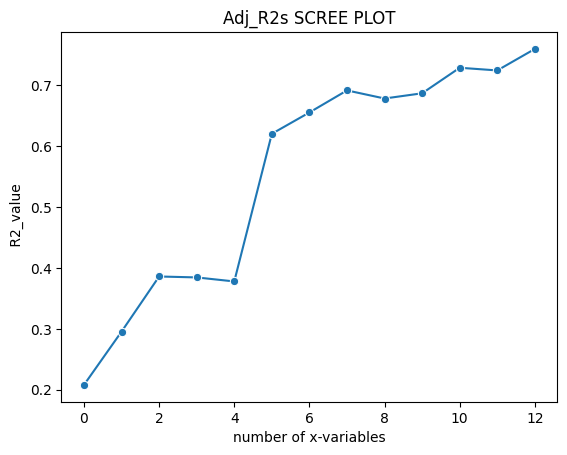

In [43]:
sbs.lineplot(Adj_R2s,marker="o")
plt.title('Adj_R2s SCREE PLOT')
plt.xlabel("number of x-variables")
plt.ylabel(' R2_value')

In [44]:
ab=X.drop(['RAD','NOX'],axis=1)

In [45]:
x_train,x_test,y_train,y_test= train_test_split(ab,Y,test_size=0.25,random_state=42)
lr=LinearRegression()
lr.fit(x_train,y_train)         # will get coefficient and intercept value to get prediction
r2= lr.score(x_test,y_test)  

In [46]:
r2

0.7467218795820554

<Axes: >

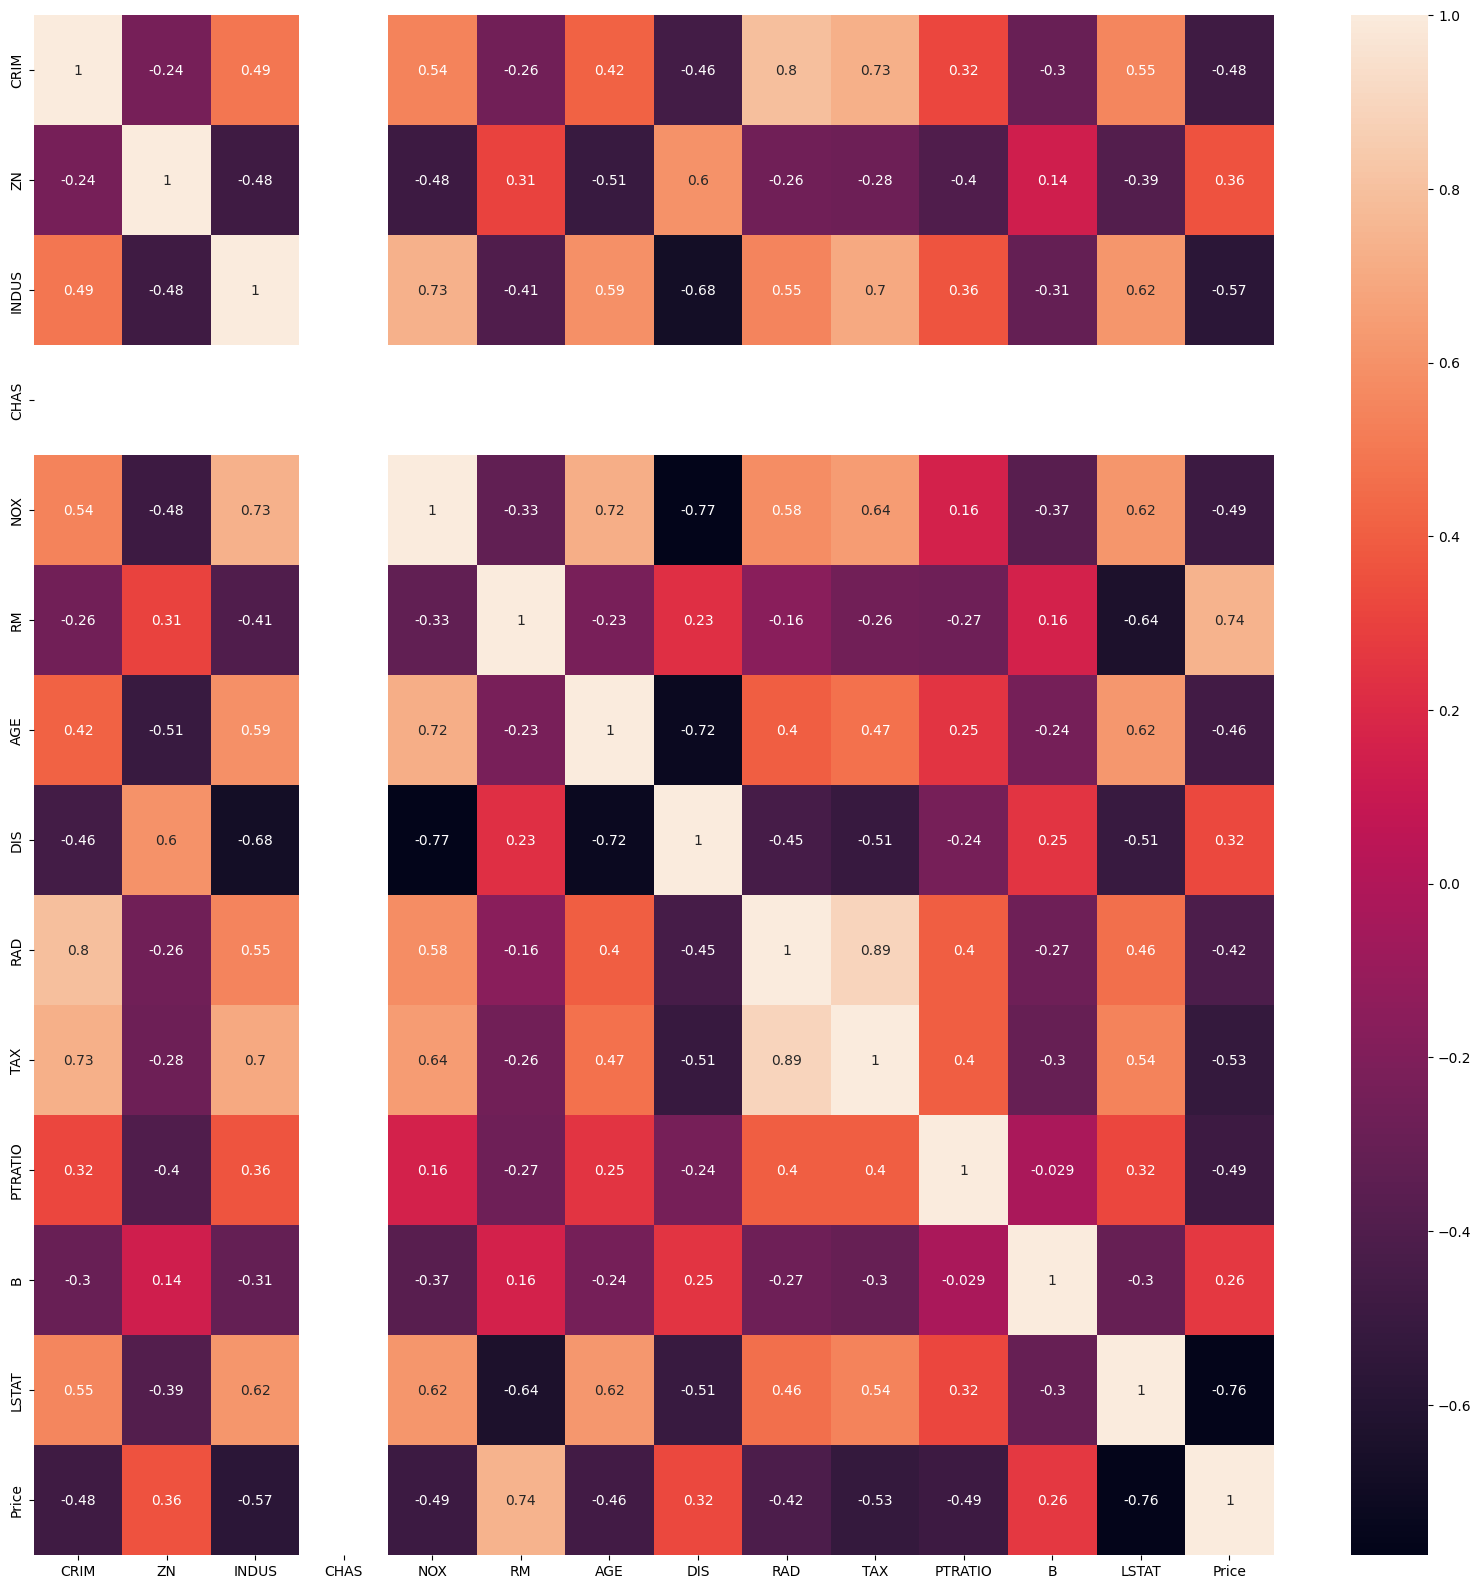

In [47]:
plt.figure(figsize=(20,20))
sbs.heatmap(boston.corr(),annot=True)

In [48]:
Ab= X[['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'RAD', 'TAX',
       'PTRATIO','LSTAT']]

In [49]:
x_train,x_test,y_train,y_test= train_test_split(Ab,Y,test_size=0.25,random_state=42)
lr=LinearRegression()
lr.fit(x_train,y_train)         # will get coefficient and intercept value to get prediction
r2= lr.score(x_test,y_test) 

In [50]:
r2

0.7365605930022351

# OPTIMIZERS (REGULARIZATION TECHNIQUES)

1. OPTIMIZE means we are trying to increase R2 value
2. REGULARIZE means we are trying to decraese the distance between R2 train and test

# REGULARIZATION TECHNIQUES
1. L1= RIDGE
2. L2= LASSO
3. ELASTICNET

In [51]:
from sklearn.linear_model import Ridge,Lasso,ElasticNet

In [52]:
L1= Ridge()
L2= Lasso()
EN= ElasticNet()

In [53]:
x_train,x_test,y_train,y_test= train_test_split(X_std,Y,test_size=0.25,random_state=42)

In [54]:
L1.fit(x_train,y_train)
print('L1 TRAINING R2 VALUE:', L1.score(x_train,y_train))
print('L1 TESTING R2 VALUE: ', L1.score(x_test,y_test))
            

L1 TRAINING R2 VALUE: 0.7955624453200689
L1 TESTING R2 VALUE:  0.7666339189615305


In [55]:
L2.fit(x_train,y_train)
print('L2 TRAINING R2 VALUE:',L2.score(x_train,y_train))
print('L2 TESTING R2 VALUE: ', L2.score(x_test,y_test))

L2 TRAINING R2 VALUE: 0.7278525245342683
L2 TESTING R2 VALUE:  0.7278196651359962


In [56]:
EN.fit(x_train,y_train)
print('EN TRAINING R2 VALUE:',EN.score(x_train,y_train))
print('EN TESTING R2 VALUE: ', EN.score(x_test,y_test))

EN TRAINING R2 VALUE: 0.7086316671332052
EN TESTING R2 VALUE:  0.712479541589877


# RIDGE LOSS FUNCTION: (Y-Y')^2/|(SLOPE)^2

In [57]:
prop= 28  # actual price of y
pred= 50  # predicted price of y

In [58]:
(prop-pred)**2+( 0.01*50)

484.5

In [59]:
lr.intercept_

np.float64(8.324169952149573)

In [60]:
lr.coef_

array([-0.06186335, -0.01597419,  0.02143803, -1.35669965,  5.91413353,
       -0.0186113 ,  0.12511945, -0.01157199, -0.78214447, -0.28688429])

In [61]:
(prop-(-prop+pred))**2+ abs(1*50)    

86

# RIDGE= Loss f(LR) +/|*(slope)**2
# LASSO= Loss f(LR) +/|*(slope)|
# ELASTICNET= Loss f(LR)+ RIDGE+LASSO

In [62]:
L1_pred=L1.predict(X_test)
L2_pred=L2.predict(X_test)
EN_pred=EN.predict(X_test)

C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but ElasticNet was fitted with feature names
  warnings.warn(


In [63]:
actual=y_test

<Axes: xlabel='Price'>

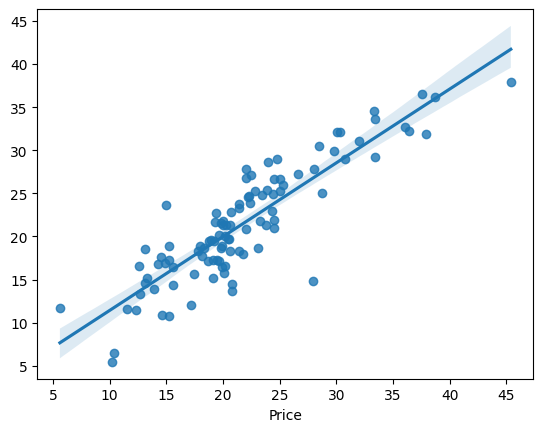

In [64]:
sbs.regplot(x=actual,y=L1_pred)

<Axes: xlabel='Price'>

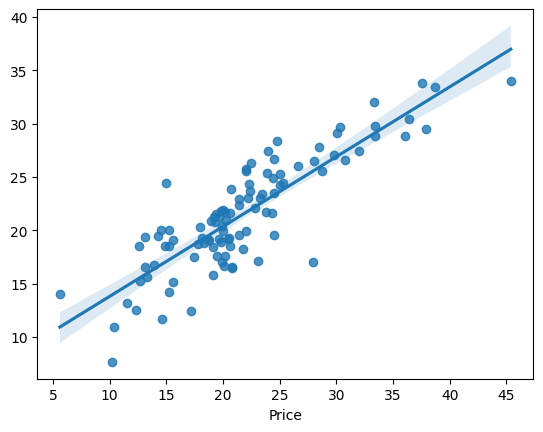

In [65]:
sbs.regplot(x=actual,y=L2_pred)

<Axes: xlabel='Price'>

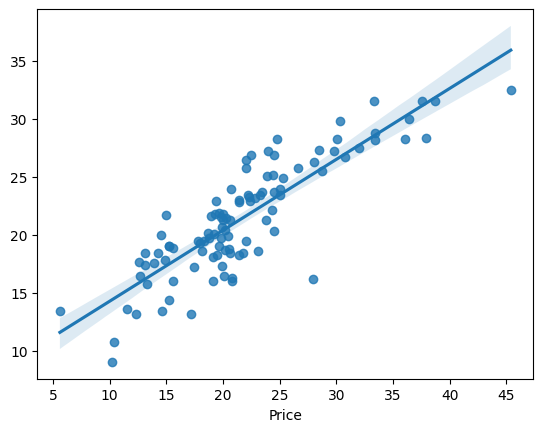

In [66]:
sbs.regplot(x=actual,y=EN_pred)

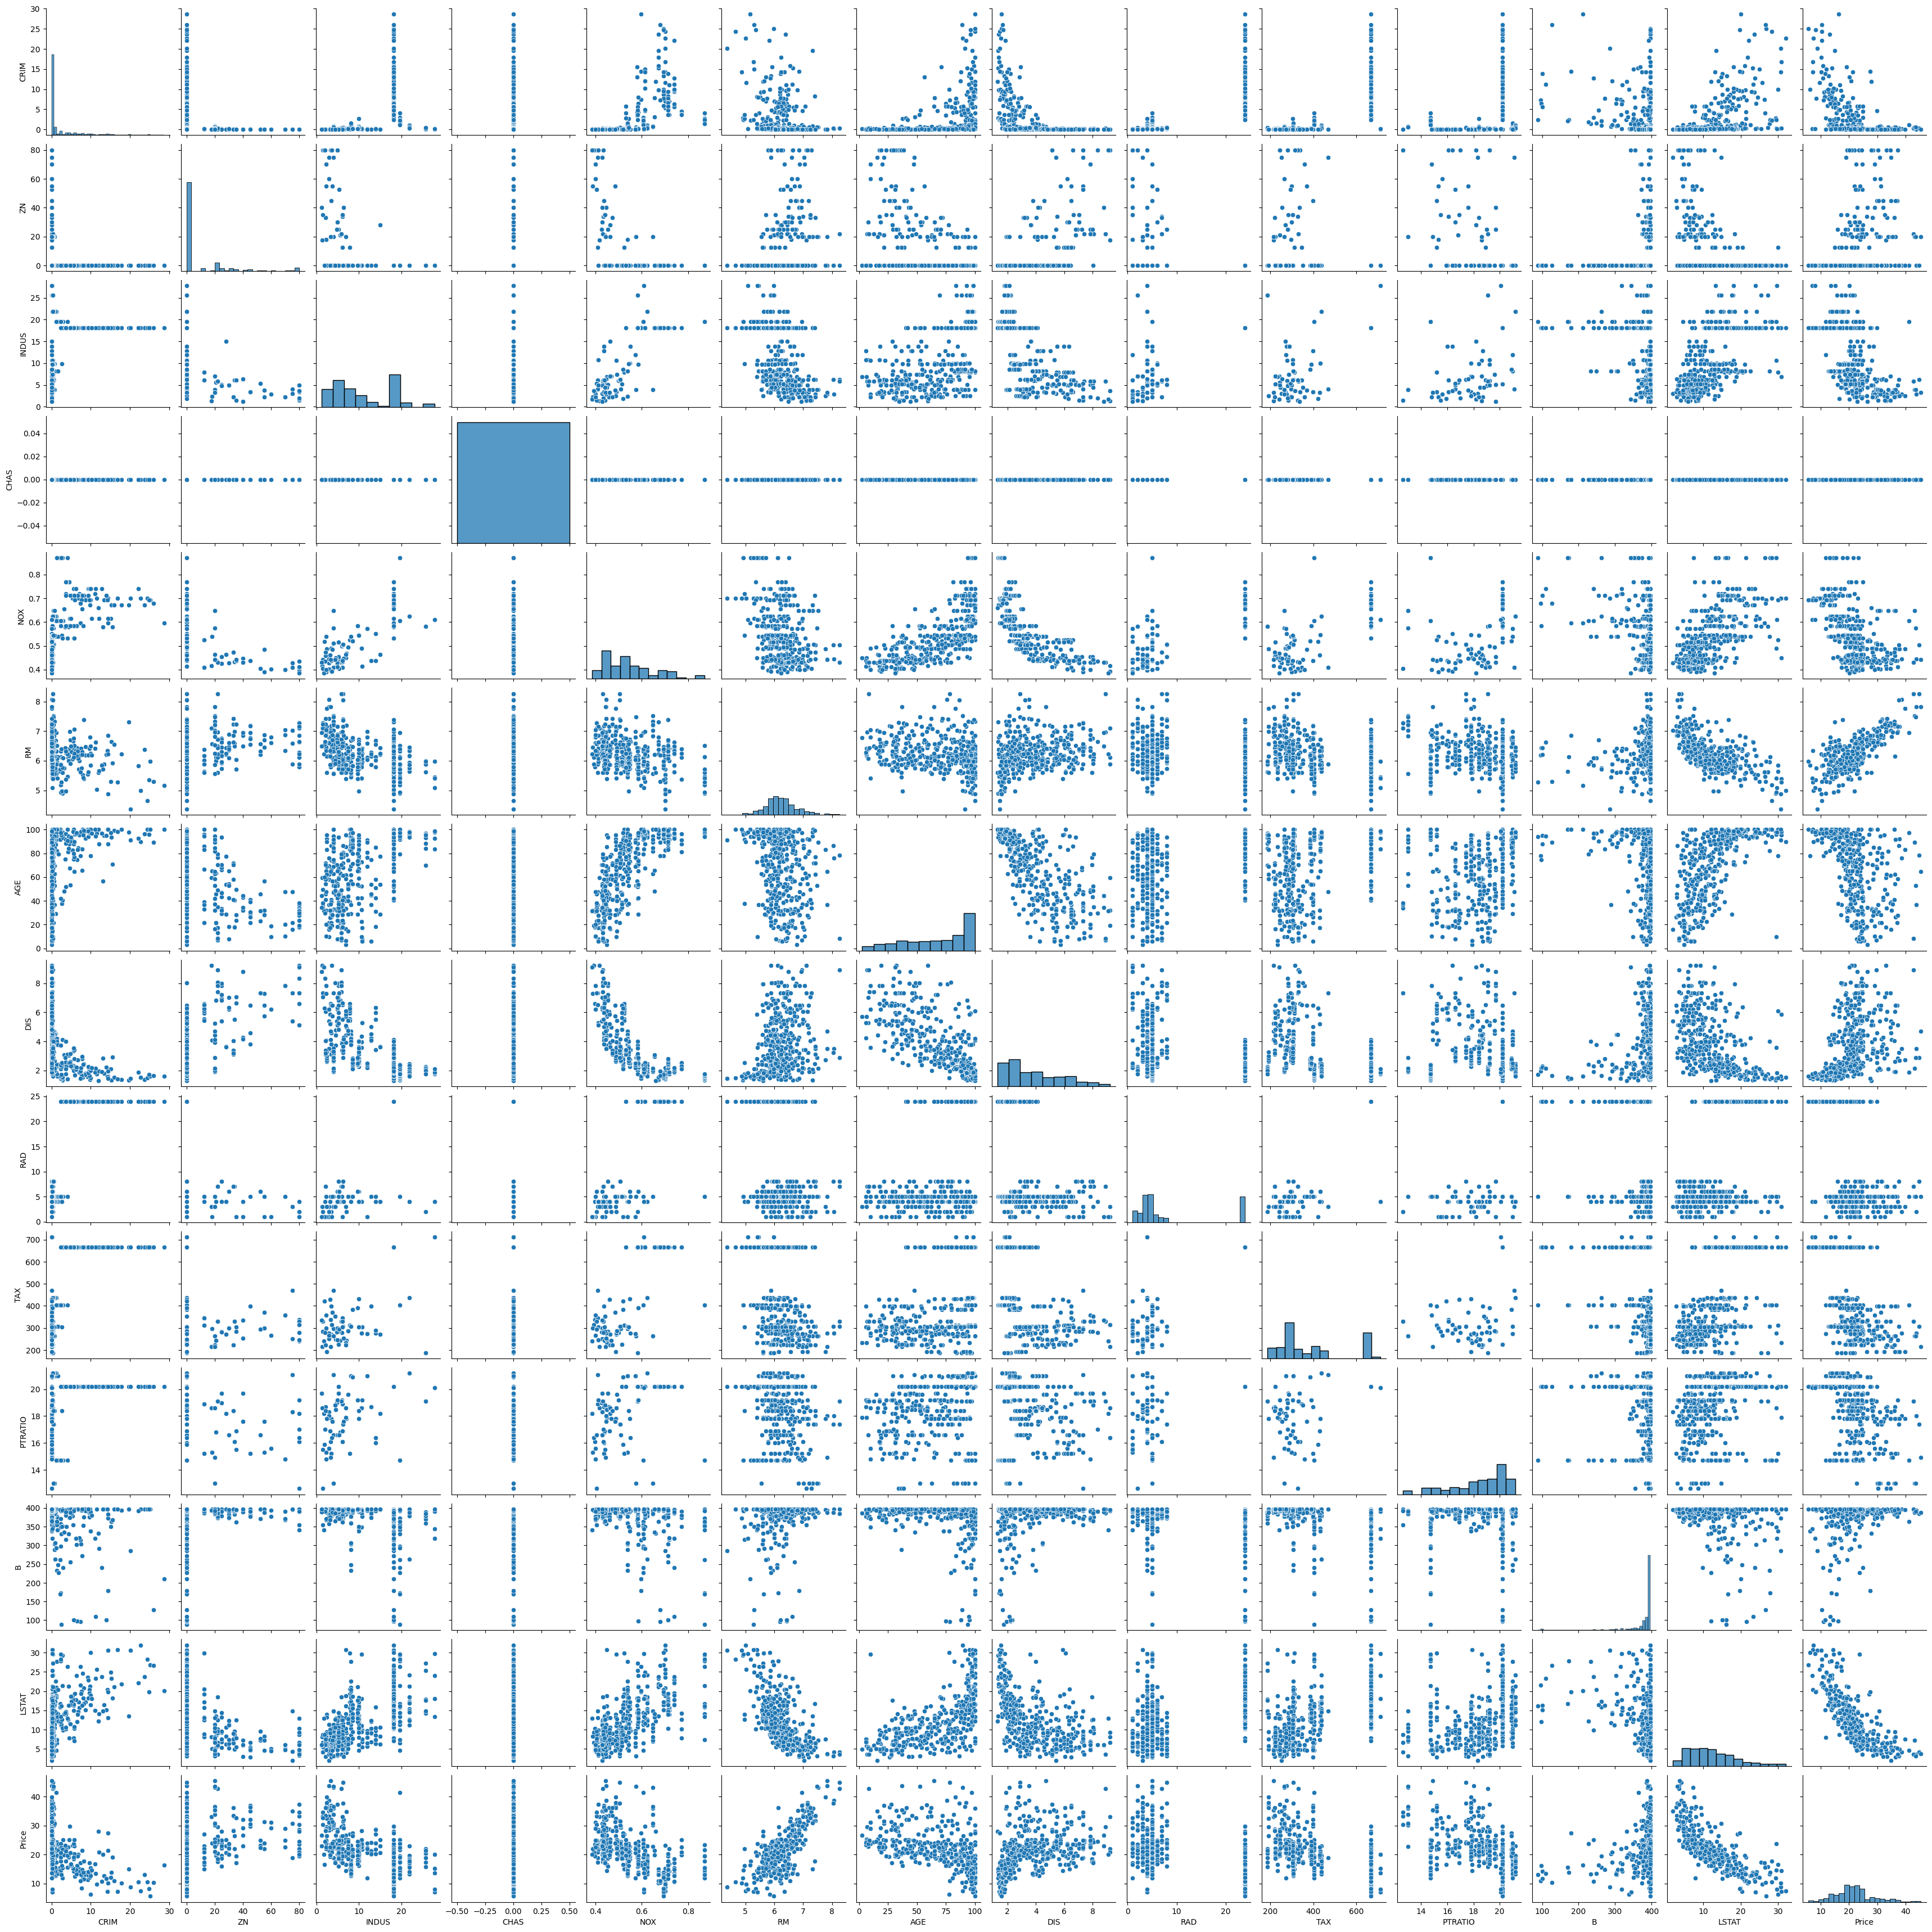

In [67]:
sbs.pairplot(boston)

# CONCLUSION 

# 1) DATA AQUISITION- {CSV FILE}
   
# 2) DATA CLEANING AND PREPROCESSING
   
    * DATA TYPE { x data to have all numeric record}
    * MISSING DATA TEST { data should not have any missing record}
    * OUTLIERS- data should not have any extreme values {noises}
      
# 3) TRAIN TEST SPLIT {SELECTION OF RECORD TO BE RANDOM}
   
    * X independent data (by which we can do prediction)
    * y dependent dat( to which we are predicting)
    * training data is use to train model
    * testing data is use to evaluate training model

# 4) Model Creating using Linear Regression
   
    * coefficient( to find M value)
    * intercept( to find the intercept value)
    * m1*x1+m2*x2.........+c (formula for prediction)
      
# 5) PERFORMANCE TESTING
   
    * MSE
    * RMSE
    * MAE
    * R2_VALUE
    * ADJUSTED R2 VALUE

# 6) OPTIMISIATION AND REGULARIZATION
   
    * OPTIMISE
    * REGULARIZE
    * OVERFITTING
    * UNDERFITTING

# Interview Based Questions

#  Q1 what all are the types of linear regression ?
Ans :
1) Simple Linear  Regression where we have single column in X data
2) Multiple Linear Regression where we have more than 1 column in X data

# Q2 what is the equation for simple linear Regression and Multiple Linear Regression ?
Ans :
1) Mx+c Simple Linear Regression
2) M1x1 + M2x2 + M3x3 ... + C is for Multiple Linear Regression

# Q3 What is the first step of cleaning and preprocessing of data for linear model  ?
Ans : Data Profilling [selection of correct data types]
      Machine understands numbers only so hence we will convert all categorical data into Numerical

# Q4 Before Using Linear Regression what all are the points that we have to check ?
Ans :
1) There should be a linear relationship between X and y
2) Error Terms should be Normally Distributed [No outliers ]
3) There should be a Homoscedascisity in Data [all data points should be near to linear line ]
4) There should not be a problem of Multicolinearity [X1 is correlated with x2,x3,x4,x5...]
   * Correlation Threshold value is >0.6 and <-0.6
5) all columns of indepepndant data should act independently


# Q5 Step by Step Define Cleaning and Preprocssing of Data before entering in model ?
Ans :
1) Data Profilling
   * all categorical data should be converted to Numeric  
2) Missing Value
3) outliers
4) correlation [Feature Engineering ]
5) Feature Scalling


# Q6 List the performance Metrics for Linear Regression ?
Ans:
    1) MSE [Mean Squared Error]
    2) RMSE [Root Mean Squared Error]
    3) MAE [Mean Absolute Error]
    4) R2 [R Squared Value ]
    5) Adjusted R Squared Value

# Q7 What is the difference between Loss and Cost Function ?
Ans :
    Loss function defines error of single prediction
    whereas Cost function defines error of all predictions

# Q8 what is the difference between overfitting and underfitting ?
Ans :
    Overfitting : when model is performing good at training but lapse at the time of testing
    undefitting : when model is not performing good in both trianning and testing
    Baseline is 0.6

In [68]:
import pickle

In [71]:
pickle.dump(lr,open('model.pkl','wb'))
pickle.dump(list(X.columns),open('columns.pkl','wb'))